In [ ]:
import matplotlib.pyplot as plt

from motion_planning.obstacle_sets import BiasedPassage
from motion_planning.search import PRM
from motion_planning.space import PointRobot

pygame 2.6.1 (SDL 2.28.4, Python 3.12.9)
Hello from the pygame community. https://www.pygame.org/contribute.html


# Setup Robot & Environment

In [2]:
env = PointRobot()
env.set_obstacles(BiasedPassage(num_walls=4))

# Create Task to Solve

In [3]:
start, target = env.sample_task()

# Initialize PRM

In [32]:
""" 
There are 2 Edge Connection Strategies: num_neighbors and edge_dist_radius

This example uses the num_neighbors method which means each node in the graph will attempt 
a fixed number of edge connections to the "num_neighbors" nearest nodes no matter the distance.

The edge_dist_radius means each node will attempt connections to all nodes within the specified 
radius. This limits the length of all edges to the specified value.
"""

prm = PRM(env, num_samples=1000, num_neighbors=10, validate_edges=True)

# Create PRM Graph

In [33]:
prm.create_graph()

Connecting Edges Using knn strategy


# Visualize PRM Graph

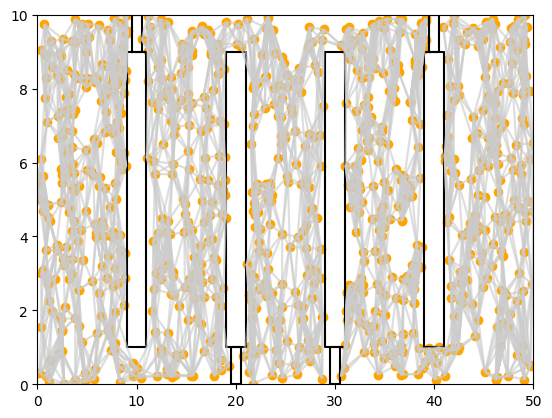

In [28]:
env.draw_environment(plt.gca())
prm.draw(plt.gca())
plt.show()

# Search Graph for Path

In [29]:
path = prm.search(start, target)

# Visualize Path within Graph

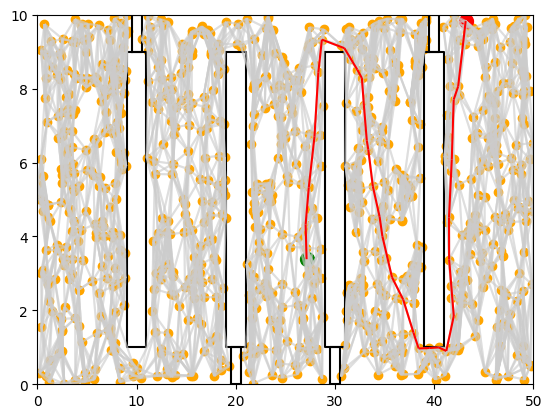

In [30]:
env.draw_environment(plt.gca())
prm.draw(plt.gca(), path=path, show_task=True)
plt.show()